Upload CONTENT image


Saving City-tree.jpg to City-tree (4).jpg
Upload STYLE image


Saving style.jpg to style (4).jpg


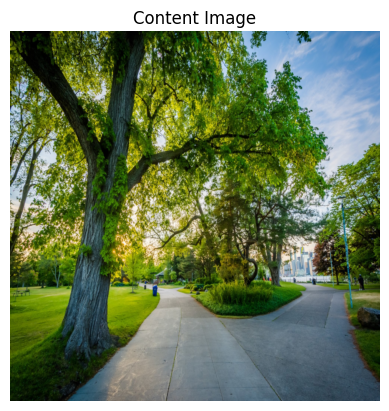

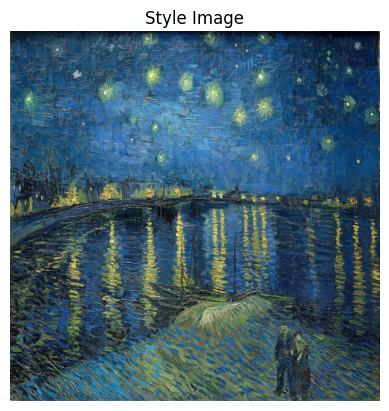

Step: 100 Total Loss: 0.3678674101829529
Step: 200 Total Loss: 0.30967238545417786
Step: 300 Total Loss: 0.29739871621131897
Step: 400 Total Loss: 0.29176560044288635
Step: 500 Total Loss: 0.2881309688091278
Step: 600 Total Loss: 0.28571465611457825
Step: 700 Total Loss: 0.2837841808795929
Step: 800 Total Loss: 0.2826559543609619
Step: 900 Total Loss: 0.281263142824173
Step: 1000 Total Loss: 0.2810588479042053
Step: 1100 Total Loss: 0.2861512303352356
Step: 1200 Total Loss: 0.2807226777076721
Step: 1300 Total Loss: 0.28527671098709106
Step: 1400 Total Loss: 0.283638060092926
Step: 1500 Total Loss: 0.28168654441833496
Step: 1600 Total Loss: 0.6091163158416748
Step: 1700 Total Loss: 0.3677857518196106
Step: 1800 Total Loss: 0.292289674282074
Step: 1900 Total Loss: 0.28847217559814453
Step: 2000 Total Loss: 0.30843812227249146


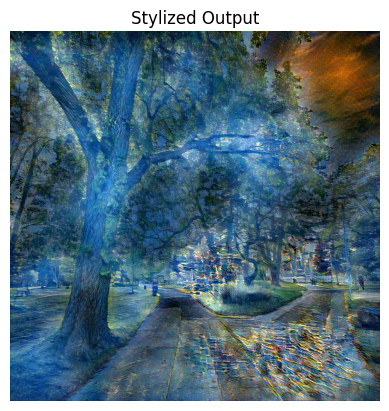

Saved stylized_output.png


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Upload CONTENT image")
content_file = files.upload()

print("Upload STYLE image")
style_file = files.upload()

content_path = list(content_file.keys())[0]
style_path = list(style_file.keys())[0]

image_size = 768

loader = transforms.Compose([
    transforms.Resize((image_size,image_size)),
    transforms.ToTensor()
])

def load_image(path):
    image = Image.open(path).convert("RGB")
    image = loader(image).unsqueeze(0)
    return image.to(device)

content = load_image(content_path)
style = load_image(style_path)

def show(img,title):
    img = img.cpu().clone().squeeze(0)
    img = transforms.ToPILImage()(img)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

show(content,"Content Image")
show(style,"Style Image")

vgg = models.vgg19(weights=VGG19_Weights.DEFAULT).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad = False

def gram_matrix(tensor):
    b,c,h,w = tensor.size()
    features = tensor.view(c, h*w)
    G = torch.mm(features,features.t())
    return G/(c*h*w)

def get_features(image, model):

    layers = {
        '0':'conv1_1',
        '5':'conv2_1',
        '10':'conv3_1',
        '19':'conv4_1',
        '21':'conv4_2',
        '28':'conv5_1'
    }

    features = {}
    x = image

    for name, layer in model._modules.items():

        x = layer(x)

        if name in layers:
            features[layers[name]] = x

    return features

content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

style_weights = {
    'conv1_1':1.0,
    'conv2_1':0.8,
    'conv3_1':0.5,
    'conv4_1':0.3,
    'conv5_1':0.1
}

target = content.clone().requires_grad_(True).to(device)

optimizer = optim.LBFGS([target])

style_weight = 1e6
content_weight = 1

steps = 2000

run = [0]

while run[0] <= steps:

    def closure():

        target.data.clamp_(0,1)

        optimizer.zero_grad()

        target_features = get_features(target,vgg)

        content_loss = torch.mean(
            (target_features['conv4_2'] - content_features['conv4_2'])**2
        )

        style_loss = 0

        for layer in style_weights:

            target_feature = target_features[layer]

            target_gram = gram_matrix(target_feature)

            style_gram = style_grams[layer]

            _,c,h,w = target_feature.shape

            layer_loss = torch.mean((target_gram-style_gram)**2)

            style_loss += style_weights[layer] * layer_loss

        total_loss = content_weight*content_loss + style_weight*style_loss

        total_loss.backward()

        run[0]+=1

        if run[0] % 100 == 0:
            print("Step:",run[0],
                  "Total Loss:",total_loss.item())

        return total_loss

    optimizer.step(closure)

target.data.clamp_(0,1)

show(target,"Stylized Output")

output = target.cpu().clone().squeeze(0)
output = transforms.ToPILImage()(output)
output.save("stylized_output.png")

print("Saved stylized_output.png")